# Multivariate Analysis on Default Payments in Taiwan

`` Exploring all the variables on the Dataset ``

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

df = pd.read_csv("default of credit card clients.csv", skiprows=1)
print("Dataset has", df.shape[0], "observations")
print("Dataset has", df.shape[1], "variables\n")


variable_names = df.columns.to_list()
print(variable_names)



Dataset has 30000 observations
Dataset has 25 variables

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


## 1 - Dependencia entre Limit Balance, PAY ,BILL e PAY_AMT

In [3]:
pay_cols    = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols   = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
focus_cols  = ['LIMIT_BAL'] + pay_cols + bill_cols + payamt_cols

df[focus_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0
PAY_6,30000.0,-0.29,1.15,-2.0,-1.00,0.0,0.00,8.0
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.08,71173.77,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.15,69349.39,-157264.0,2666.25,20088.5,60164.75,1664089.0


```Distribuição das variáveis```

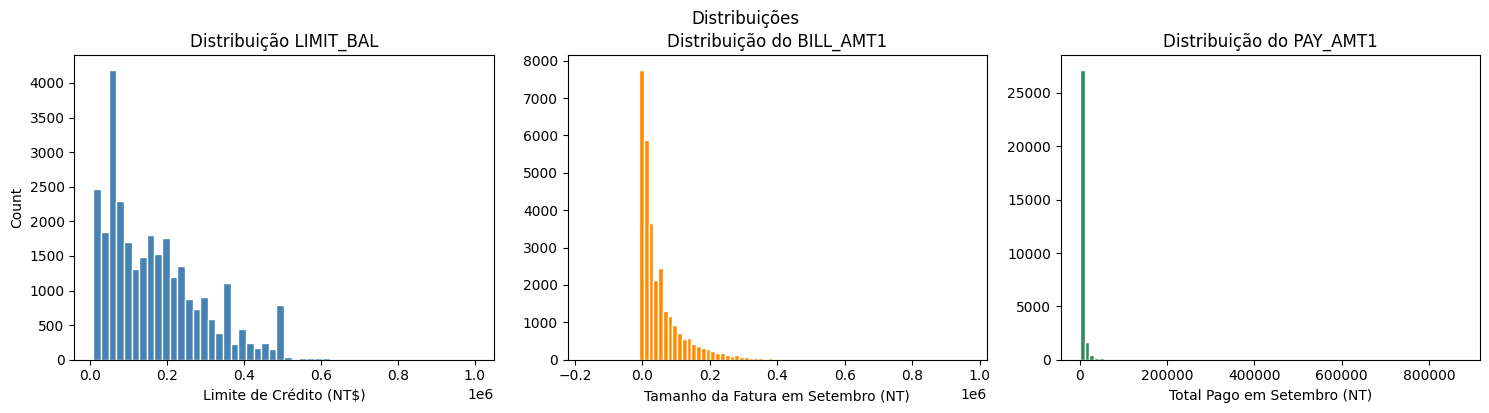

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# LIMIT_BAL
axes[0].hist(df['LIMIT_BAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição LIMIT_BAL')
axes[0].set_xlabel('Limite de Crédito (NT$)')
axes[0].set_ylabel('Count')

# BILL_AMT1
axes[1].hist(df['BILL_AMT1'], bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição do BILL_AMT1')
axes[1].set_xlabel('Tamanho da Fatura em Setembro (NT)')

# PAY_AMT1
axes[2].hist(df['PAY_AMT1'], bins=80, color='seagreen', edgecolor='white')
axes[2].set_title('Distribuição do PAY_AMT1')
axes[2].set_xlabel('Total Pago em Setembro (NT)')

plt.tight_layout()
plt.suptitle('Distribuições', y=1.02, fontsize=12)
plt.show()

```Correlações de Spearman e Pearson```

Mapas de calor

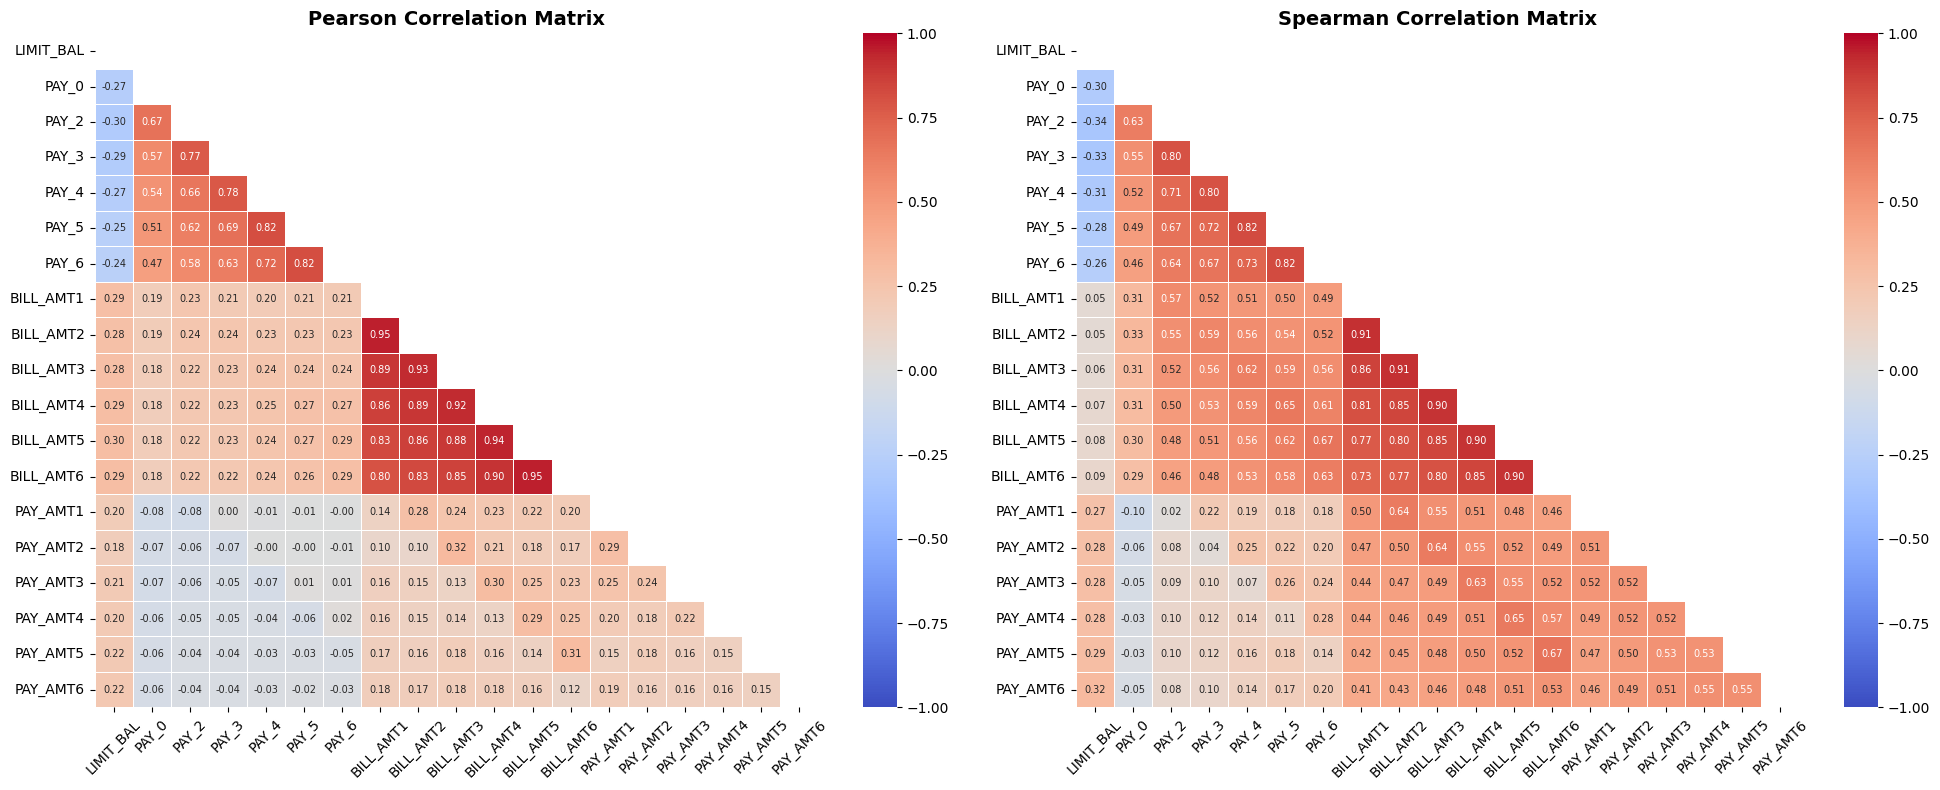

In [5]:
pearson  = df[focus_cols].corr(method='pearson')
spearman = df[focus_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(pearson, dtype=bool))

for ax, corr_mat, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    sns.heatmap(
        corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        vmin=-1, vmax=1, center=0, linewidths=0.4, ax=ax,
        annot_kws={'size': 7}
    )
    ax.set_title(f'{title} Correlation Matrix', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

```Bill Amount ao longo do tempo```

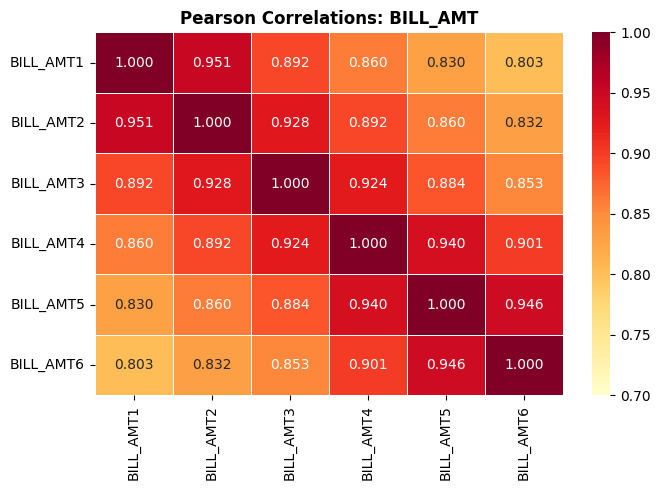

In [13]:
bill_corr = df[bill_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(bill_corr, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.7, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlations: BILL_AMT', fontweight='bold')
plt.tight_layout()
plt.show()

```Pay amount ao longo do tempo```

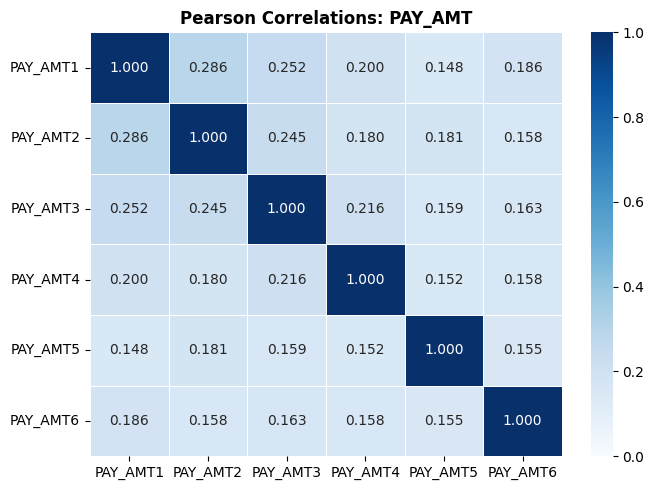

In [7]:
payamt_corr = df[payamt_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(payamt_corr, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlations: PAY_AMT', fontweight='bold')
plt.tight_layout()
plt.show()

```Limit Bal vs Bill AMT1```

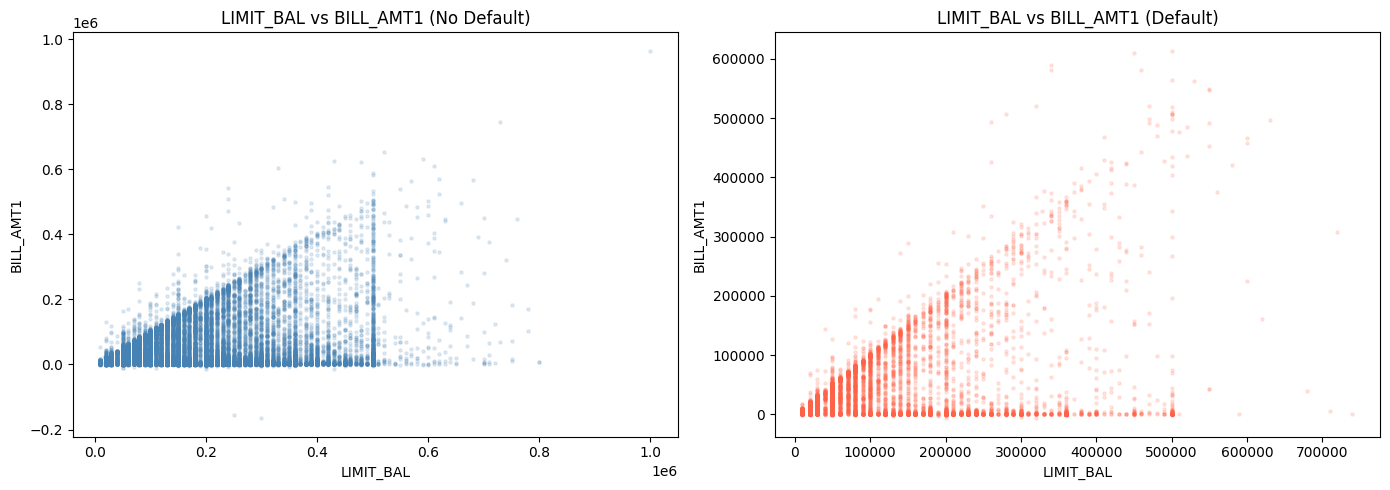

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Default', 1: 'Default'}

for default_val, ax, title in zip(
        [0, 1], axes, ['LIMIT_BAL vs BILL_AMT1 (No Default)', 'LIMIT_BAL vs BILL_AMT1 (Default)']):
    sub = df[df['default payment next month'] == default_val]
    ax.scatter(sub['LIMIT_BAL'], sub['BILL_AMT1'],
               alpha=0.15, s=5, color=colors[default_val])
    ax.set_xlabel('LIMIT_BAL')
    ax.set_ylabel('BILL_AMT1')
    ax.set_title(title)

plt.tight_layout()
plt.show()

```Pay 0 vs Default payment next month```

       Not Default (%)  Default (%)
PAY_0                              
-2                86.8         13.2
-1                83.2         16.8
 0                87.2         12.8
 1                66.1         33.9
 2                30.9         69.1
 3                24.2         75.8
 4                31.6         68.4
 5                50.0         50.0
 6                45.5         54.5
 7                22.2         77.8
 8                42.1         57.9


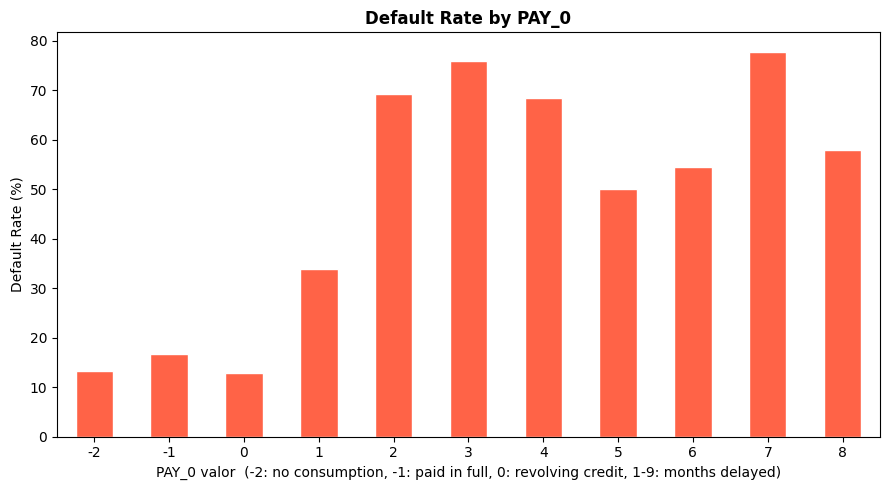

In [15]:
ct = pd.crosstab(df['PAY_0'], df['default payment next month'], normalize='index') * 100
ct.columns = ['Not Default (%)', 'Default (%)']
print(ct.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
ct['Default (%)'].plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Default Rate by PAY_0', fontweight='bold')
ax.set_xlabel('PAY_0 valor  (-2: no consumption, -1: paid in full, 0: revolving credit, 1-9: months delayed)')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(ct.index, rotation=0)
plt.tight_layout()
plt.show()

```LIMIT_BAL vs PAY_AMT1```

/tmp/ipykernel_12571/1800577850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='DEFAULT_LABEL', y='LIMIT_BAL',
/tmp/ipykernel_12571/1800577850.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_capped, x='DEFAULT_LABEL', y='PAY_AMT1',


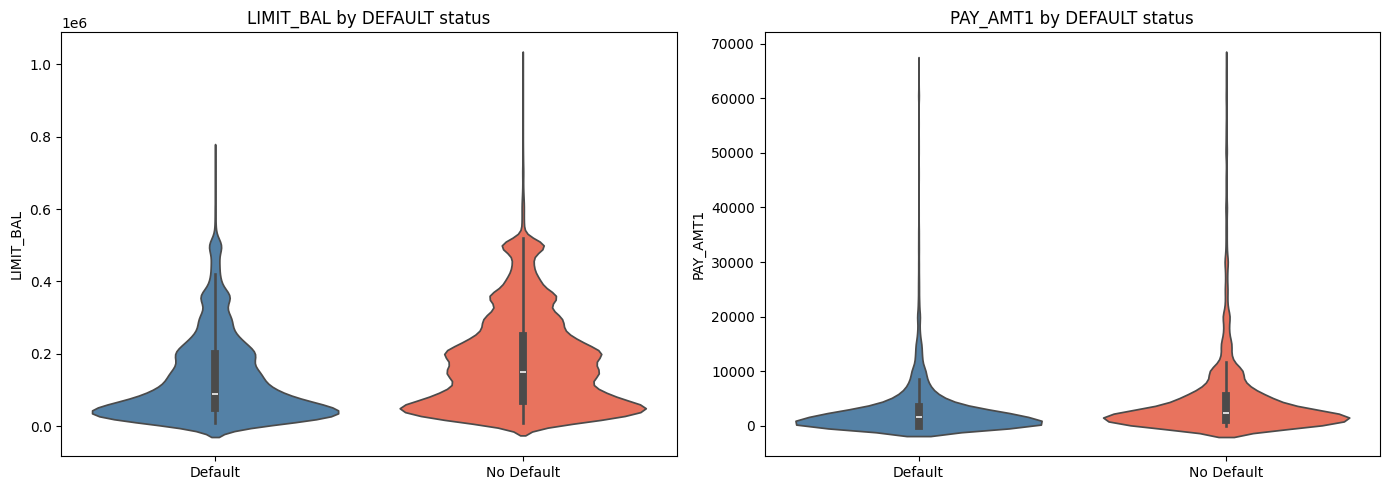

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot['DEFAULT_LABEL'] = df_plot['default payment next month'].map({0: 'No Default', 1: 'Default'})

sns.violinplot(data=df_plot, x='DEFAULT_LABEL', y='LIMIT_BAL',
               palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('LIMIT_BAL by DEFAULT status')
axes[0].set_xlabel('')

# Cap PAY_AMT1 for readability
df_capped = df_plot[df_plot['PAY_AMT1'] < df_plot['PAY_AMT1'].quantile(0.99)]
sns.violinplot(data=df_capped, x='DEFAULT_LABEL', y='PAY_AMT1',
               palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('PAY_AMT1 by DEFAULT status')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 2. Pearson vs Spearman

In [11]:
x = df['BILL_AMT1']
y = df['PAY_AMT1']

pearson_r,  pearson_p  = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print('=== BILL_AMT1 vs PAY_AMT1 ===')
print(f'Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.2e})')
print(f'Spearman r = {spearman_r:.4f}  (p = {spearman_p:.2e})')
print(f'\nDifference: {abs(spearman_r - pearson_r):.4f}')

=== BILL_AMT1 vs PAY_AMT1 ===
Pearson  r = 0.1403  (p = 1.14e-131)
Spearman r = 0.5023  (p = 0.00e+00)

Difference: 0.3621


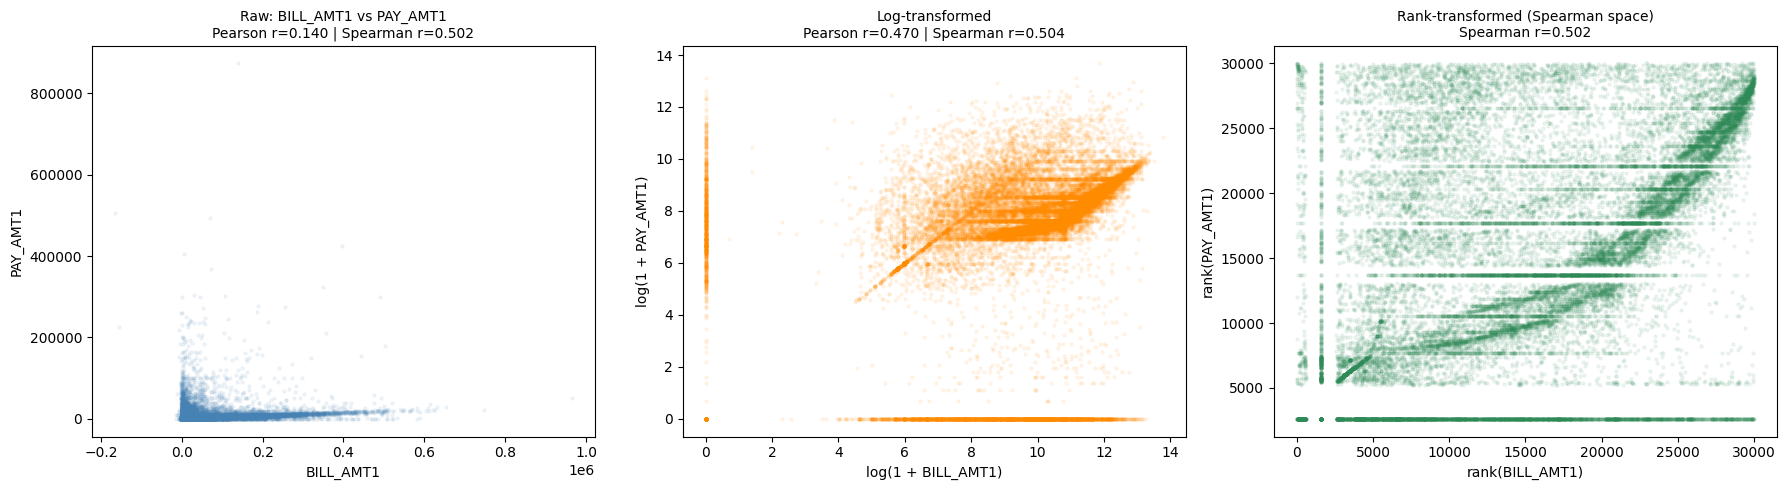

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Raw scatter (problematic for Pearson) ---
axes[0].scatter(x, y, alpha=0.07, s=5, color='steelblue')
axes[0].set_title(f'Raw: BILL_AMT1 vs PAY_AMT1\nPearson r={pearson_r:.3f} | Spearman r={spearman_r:.3f}',
                  fontsize=10)
axes[0].set_xlabel('BILL_AMT1')
axes[0].set_ylabel('PAY_AMT1')

# --- Plot 2: Log-transformed scatter ---
x_log = np.log1p(x.clip(lower=0))
y_log = np.log1p(y.clip(lower=0))
r_log_pearson, _ = stats.pearsonr(x_log, y_log)
r_log_spearman, _ = stats.spearmanr(x_log, y_log)

axes[1].scatter(x_log, y_log, alpha=0.07, s=5, color='darkorange')
axes[1].set_title(f'Log-transformed\nPearson r={r_log_pearson:.3f} | Spearman r={r_log_spearman:.3f}',
                  fontsize=10)
axes[1].set_xlabel('log(1 + BILL_AMT1)')
axes[1].set_ylabel('log(1 + PAY_AMT1)')

# --- Plot 3: Ranks scatter (what Spearman uses) ---
axes[2].scatter(stats.rankdata(x), stats.rankdata(y), alpha=0.07, s=5, color='seagreen')
axes[2].set_title(f'Rank-transformed (Spearman space)\nSpearman r={spearman_r:.3f}',
                  fontsize=10)
axes[2].set_xlabel('rank(BILL_AMT1)')
axes[2].set_ylabel('rank(PAY_AMT1)')

plt.tight_layout()
plt.show()